In [19]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Read the dataset

data_dir = os.path.join("..", "data") if os.path.exists(os.path.join("..", "data")) else "data"

file_path = os.path.join(data_dir, "umbria_housing_model_ready.csv")

df = pd.read_csv(file_path)
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Remove unnecessary columns(like year)
housing_data = df.drop(["Comune_Key", "Anno"], axis=1, errors='ignore')


target_col = "Prezzo_Medio_Mq"

X_pandas = housing_data.drop(target_col, axis=1)
y_pandas = housing_data[target_col]

# Get target and features as np arrays
X = X_pandas.to_numpy(dtype=np.float32)
y = y_pandas.to_numpy(dtype=np.float32)

print(f"Shape of (X): {X.shape}")
print(f"Shape of (y): {y.shape}")
print(f"Data type: {type(X)}")

Shape of (X): (460, 15)
Shape of (y): (460,)
Data type: <class 'numpy.ndarray'>


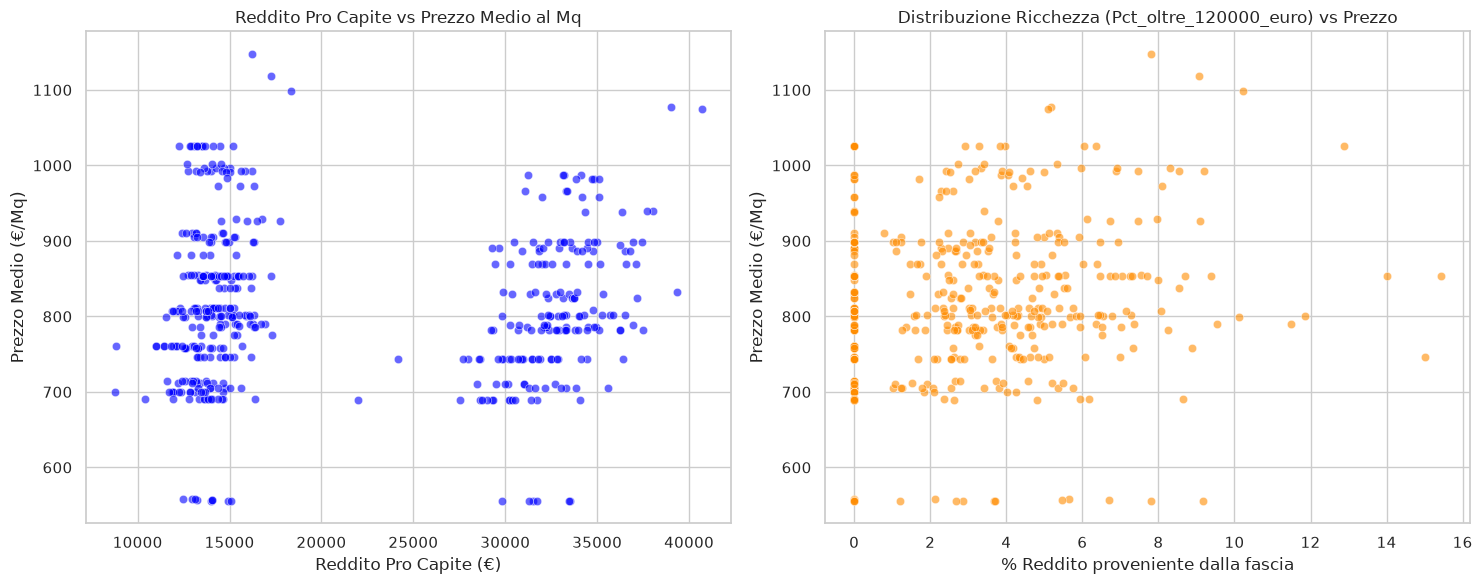

In [7]:
# Plot some key features

sns.set_theme(style="whitegrid")

# 2. Scatter Plots: Feature vs Target
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot A: Reddito Pro Capite vs Prezzo
sns.scatterplot(data=df, x='Reddito_Pro_Capite', y='Prezzo_Medio_Mq', 
                alpha=0.6, color='blue', ax=axes[0])
axes[0].set_title('Reddito Pro Capite vs Prezzo Medio al Mq')
axes[0].set_xlabel('Reddito Pro Capite (€)')
axes[0].set_ylabel('Prezzo Medio (€/Mq)')

# Trova dinamicamente una fascia di reddito alta (es. oltre 55k o 120k)
fascia_alta = [c for c in df.columns if 'Pct_' in c and ('55000' in c or '120000' in c)]
if fascia_alta:
    col_fascia = fascia_alta[-1] # Prende l'ultima fascia alta disponibile
    
    # Plot B: % Fascia Alta vs Prezzo
    sns.scatterplot(data=df, x=col_fascia, y='Prezzo_Medio_Mq', 
                    alpha=0.6, color='darkorange', ax=axes[1])
    axes[1].set_title(f'Distribuzione Ricchezza ({col_fascia}) vs Prezzo')
    axes[1].set_xlabel(f'% Reddito proveniente dalla fascia')
    axes[1].set_ylabel('Prezzo Medio (€/Mq)')

plt.tight_layout()
plt.show()

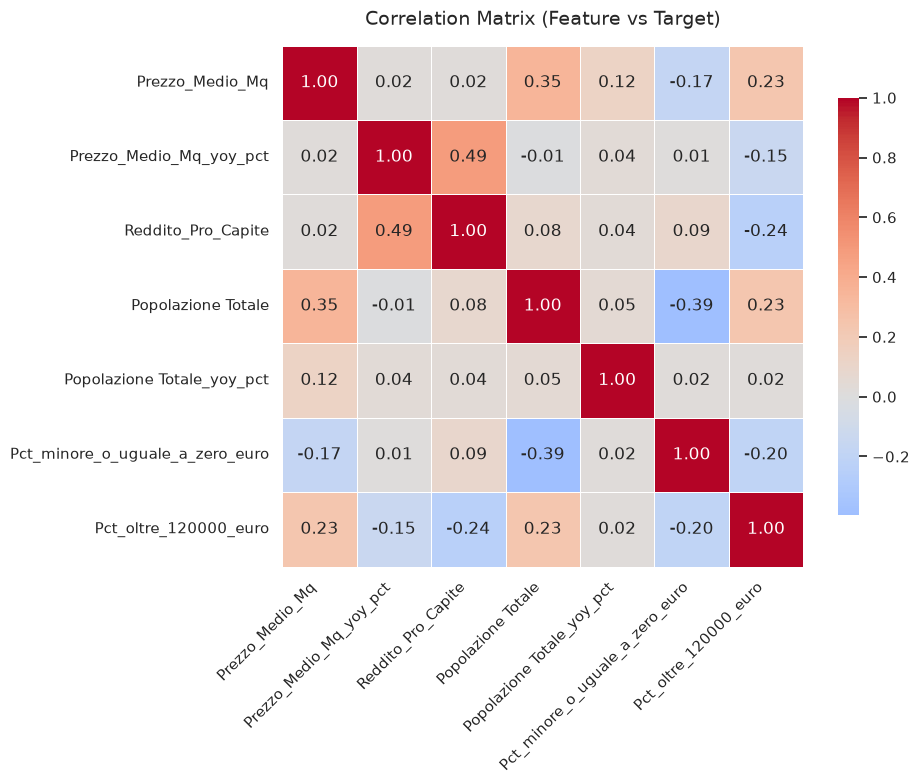

In [20]:
# Select a few important features
core_columns = [
    'Prezzo_Medio_Mq', 
    'Prezzo_Medio_Mq_yoy_pct',
    'Reddito_Pro_Capite', 
    'Popolazione Totale', 
    'Popolazione Totale_yoy_pct'
]

# Aggiungiamo un paio di fasce percentuali rappresentative (bassa e alta)
fasce_campione = [c for c in df.columns if 'Pct_' in c]
if len(fasce_campione) >= 2:
    core_columns.extend([fasce_campione[0], fasce_campione[-1]])

# Calcolo della matrice di correlazione di Pearson
corr_matrix = df[core_columns].corr()

# Disegno della Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, 
            square=True, linewidths=.5, cbar_kws={"shrink": .8})

plt.title("Correlation Matrix (Feature vs Target)", fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

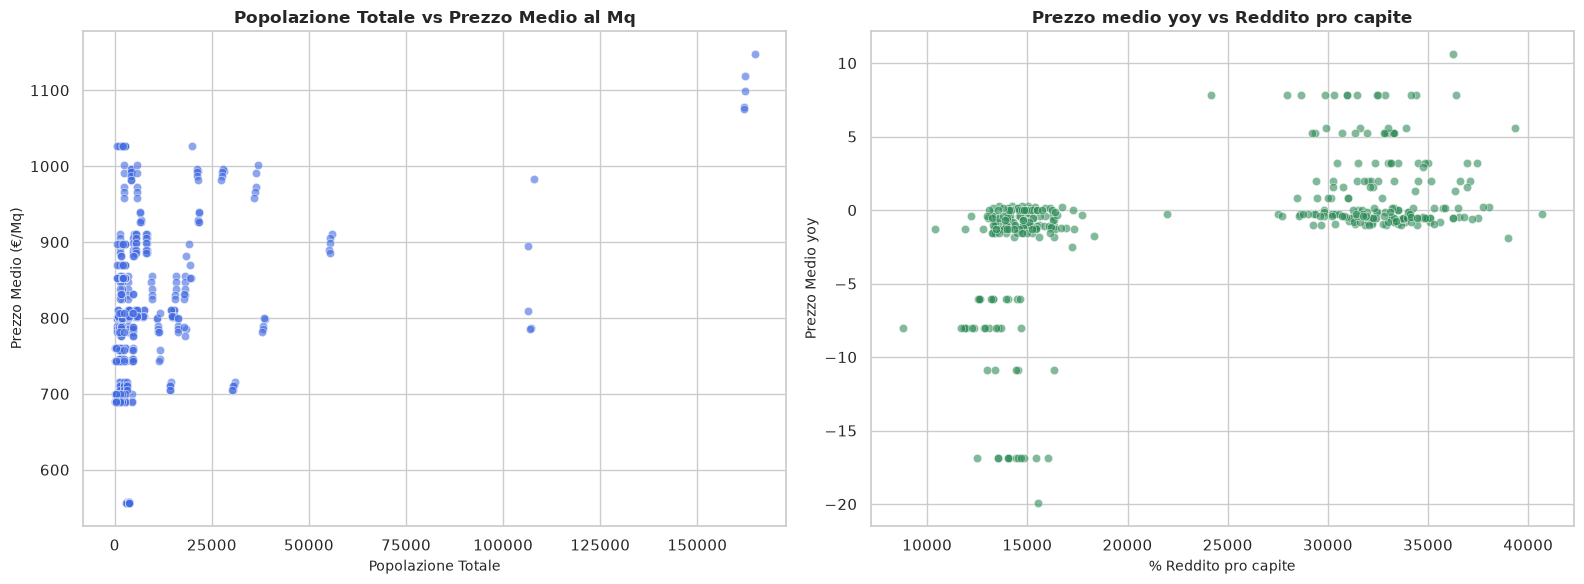

In [21]:
sns.set_theme(style="whitegrid")

# 2. Creazione dei grafici a dispersione per le metriche chiave
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Reddito Pro Capite vs Prezzo Medio al Mq
sns.scatterplot(
    data=df, 
    x='Popolazione Totale', 
    y='Prezzo_Medio_Mq', 
    alpha=0.6, 
    color='royalblue', 
    ax=axes[0]
)
axes[0].set_title('Popolazione Totale vs Prezzo Medio al Mq', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Popolazione Totale', fontsize=10)
axes[0].set_ylabel('Prezzo Medio (€/Mq)', fontsize=10)


sns.scatterplot(
    data=df, 
    x='Reddito_Pro_Capite', 
    y='Prezzo_Medio_Mq_yoy_pct', 
    alpha=0.6, 
    color='seagreen', 
    ax=axes[1]
)
axes[1].set_title(f'Prezzo medio yoy vs Reddito pro capite', fontsize=12, fontweight='bold')
axes[1].set_xlabel(f'% Reddito pro capite', fontsize=10)
axes[1].set_ylabel('Prezzo Medio yoy', fontsize=10)

plt.tight_layout()
plt.show()

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, RandomizedSearchCV, train_test_split
from sklearn.linear_model import Ridge
from sklearn.impute import SimpleImputer
from scipy.stats import randint

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

imputer = SimpleImputer(strategy="median")
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Randomized search
param_distribs = {
    'n_estimators': randint(50, 300),
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5),
    'max_features': ['sqrt', 'log2', 0.5, 0.8]
}

# Random Fores
rnd_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_distribs,
    n_iter=20,          # Number of combinations tested
    cv=5,               # Cross-validation 5 fold
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1           
)

# Fit
rnd_search.fit(X_train_scaled, y_train)

# Results
best_rmse = -rnd_search.best_score_
print(f"Best RMSE in Cross-Validation: {best_rmse:.2f} €/Mq")
print("Best hyperparameters found:")
for param, value in rnd_search.best_params_.items():
    print(f" - {param}: {value}")

# Test set evaluation
final_model = rnd_search.best_estimator_
y_pred = final_model.predict(X_test_scaled)

from sklearn.metrics import root_mean_squared_error, r2_score
test_rmse = root_mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

print(f"\nRisultati sul Test Set:")
print(f"Test RMSE: {test_rmse:.2f} €/Mq")
print(f"Test R² Score: {test_r2:.4f}")

Best RMSE in Cross-Validation: 77.08 €/Mq
Best hyperparameters found:
 - max_depth: None
 - max_features: 0.8
 - min_samples_leaf: 1
 - min_samples_split: 2
 - n_estimators: 268

Risultati sul Test Set:
Test RMSE: 60.05 €/Mq
Test R² Score: 0.6603


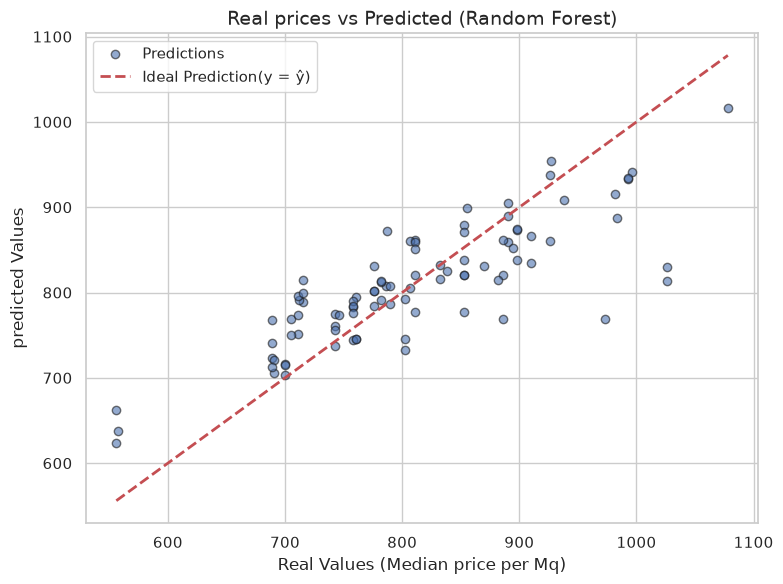

In [27]:
y_pred = final_model.predict(X_test_scaled)

# Plot dei valori reali vs predetti
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='b', edgecolor='k', label="Predictions")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label="Ideal Prediction(y = ŷ)")

plt.xlabel("Real Values (Median price per Mq)", fontsize=12)
plt.ylabel("predicted Values", fontsize=12)
plt.title("Real prices vs Predicted (Random Forest)", fontsize=14)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
from sklearn.ensemble import GradientBoostingRegressor
from scipy.stats import uniform
from sklearn.metrics import root_mean_squared_error, r2_score

# 1. Definizione dello spazio di ricerca per il Gradient Boosting
param_dist_gbr = {
    'n_estimators': randint(50, 150),
    'learning_rate': uniform(0.01, 0.15),      # Tasso di apprendimento (shrinkage)
    'max_depth': randint(2, 6),               # Alberi più snelli per il boosting
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5),
    'subsample': uniform(0.7, 0.3)            # Stochastic Gradient Boosting
}

# 2. Configurazione della RandomizedSearchCV
gbr_search = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_distributions=param_dist_gbr,
    n_iter=30,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

# 3. Addestramento sul training set scalato
gbr_search.fit(X_train_scaled, y_train)

# 4. Estrazione del miglior modello e valutazione sul test set
best_gbr = gbr_search.best_estimator_
y_pred_gbr = best_gbr.predict(X_test_scaled)

test_rmse_gbr = root_mean_squared_error(y_test, y_pred_gbr)
test_r2_gbr = r2_score(y_test, y_pred_gbr)

print(f"Miglior RMSE in CV (GBR): {-gbr_search.best_score_:.2f} €/Mq")
print(f"Test RMSE (GBR): {test_rmse_gbr:.2f} €/Mq")
print(f"Test R² Score (GBR): {test_r2_gbr:.4f}")
print("Migliori iperparametri:", gbr_search.best_params_)

Miglior RMSE in CV (GBR): 69.12 €/Mq
Test RMSE (GBR): 60.54 €/Mq
Test R² Score (GBR): 0.6547
Migliori iperparametri: {'learning_rate': np.float64(0.1375057866684699), 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 97, 'subsample': np.float64(0.8112454756594799)}
